**Общая структура и Основные агенты:**

Маршрутизатор — будет анализировать запрос пользователя и направлять его к нужным агентам. Агенты — выполняют свои специфические задачи:

Выявитель и обработчик потребностей — выявляет потребность в вопросе и помогает родителям определить, какие курсы подойдут их ребенку, исходя из интересов, возраста и потребностей.

Выявитель и обработчик возражений — выявляет возражение в вопросе и отвечает на вопросы и возражения, связанные с ценой, доступностью, сложностью курсов и т.д.

Презентатор курсов — предоставляет информацию о курсах, их преимуществах и стоимости.

Психолог — отвечает за анализ психоэмоционального состояния ребенка и помощь родителям в принятии решения.

Логопед — работает, если родитель указывает на проблемы с речью или коммуникативными навыками ребенка.

Составитель расписания — помогает составить сбалансированное расписание для ребенка, чтобы избежать перегрузки.

Обработчик ответа - анализирует ответы агентов и собирает один релевантный ответ для Клиента

Финализатор - запрашивает и подтверждает контактные данные

Дополнительные

1. Извлечение ключевых слов
2. Саммаризация  
Они помогают повысить точность и качество работы системы. Извлечение ключевых слов используется для выявления интересов и возражений, потребностей и преимуществ, а саммаризация помогает быстро сжать и представить важную информацию для агентов.
3. Агент-аналитик   
- Мониторит диалог:  
отслеживает весь процесс взаимодействия с клиентом, включая выявление потребностей, обработку возражений, рекомендации по курсам и финализацию продажи. Он будет собирать информацию о том, какие курсы интересуют клиента, какие возражения были выдвинуты, какие решения были приняты.
- Анализ:  
Агент может следить за тем, как проходят диалоги с клиентами и на основе этого перенастроить план продаж на будущее, определяя, какие курсы наиболее популярны или какие возражения наиболее часто встречаются и помогая улучшить стратегию продаж, анализируя данные по наиболее часто задаваемым вопросам, интересующим курсам, и общим предпочтениям родителей.  
Например, если клиент часто задает вопросы о стоимости, агент может предложить дополнительную информацию о скидках или сделать упор на финансовые преимущества курсов.  
- Оптимизация работы агентов:  
Агент-аналитик может предложить изменения в работе других агентов, если они слишком часто сталкиваются с одними и теми же возражениями или вопросами. Например, если психолог часто работает с родителями, испытывающими стресс из-за стоимости, агент может предложить интеграцию с обработчиком возражений для улучшения опыта клиента.

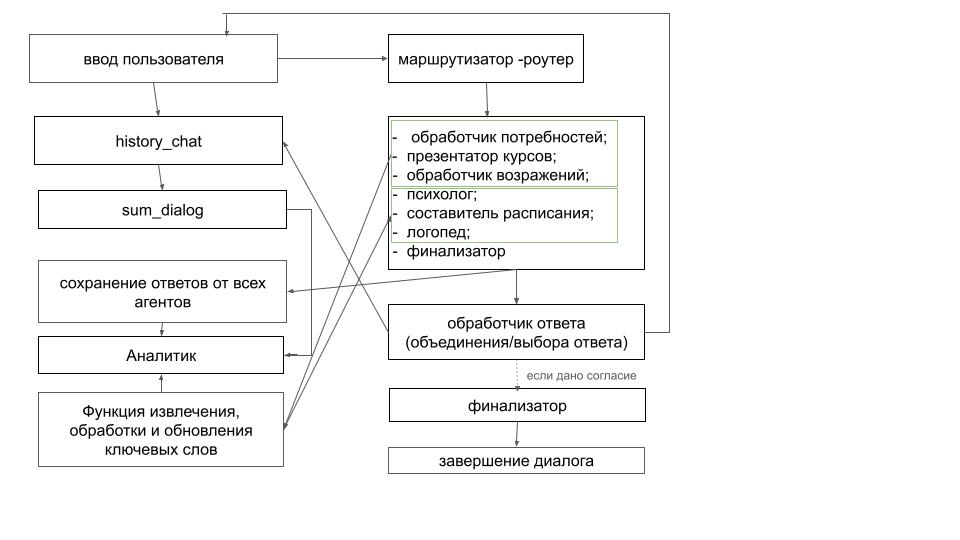

# Алгоритм:

## Загружаем библиотеки, модули, ключ openAI

In [ ]:
!pip install -q langchain_openai==0.3.24 faiss-cpu==1.11.0 openai==1.86.0 langchain-core==0.3.65 langchain==0.3.25 langchain_community==0.3.25 langchain-text-splitters==0.3.8

In [ ]:
# импортируем необходимые библиотеки
from openai import OpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain.docstore.document import Document
import os
import re
import requests
import textwrap
from textwrap import fill
import datetime
from google.colab import drive
from google.colab import userdata
import json
import time

In [ ]:
# Получение API ключа из пользовательских данных Colab и установка его как переменной среды
key = userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = key

# Создание клиента OpenAI с использованием API ключа из переменных среды
client = OpenAI()

## Задаем константы, переменные и загружаем базу

In [ ]:
# Настройки модели OpenAI
MODEL = "gpt-4o-mini"
VERBOSE = 0

# История общения с клиентом
history_chat = []  # Полная история общения
sum_dialog = ''    # саммаризованный диалог

# другие переменные
needs = []  # Список выявленных потребностей
benefits = []  # Список озвученных преимуществ
objections = []  # Список возражений
agents_responses = [] # текущие ответы от агентов
all_agents_responses = [] # все ответы от агентов

knowledge_db_url = "https://docs.google.com/document/d/1lb7eKFitx21ndKfPoVRNui-GS3OQseuwalUkZ2Z-5HE/edit?usp=sharing"

In [ ]:
# функция для загрузки документа по ссылке из гугл драйв
def load_document_text(url: str) -> str:
    # Extract the document ID from the URL
    match_ = re.search('/document/d/([a-zA-Z0-9-_]+)', url)
    if match_ is None:
        raise ValueError('Invalid Google Docs URL')
    doc_id = match_.group(1)

    # Download the document as plain text
    response = requests.get(f'https://docs.google.com/document/d/{doc_id}/export?format=txt')
    response.raise_for_status()
    text = response.text

    return text

In [ ]:
def duplicate_headers_without_hashes(text):
    """
    Дублирует заголовки в тексте, убирая из дубликатов хэши.
    """

    # Вспомогательная функция, которая будет вызываться для каждого найденного совпадения в тексте
    def replacer(match):
        # match.group() вернет найденный заголовок с хэшами.
        # затем мы добавляем к нему перенос строки и ту же строку, но без хэшей
        return match.group() + "\n" + match.group().replace("#", "").strip()

    # re.sub ищет в тексте все заголовки, начинающиеся с 1 до 2 хэшей, и заменяет их
    # с помощью функции replacer
    result = re.sub(r'#{1,2} .+', replacer, text)

    return result

In [ ]:
database = load_document_text(knowledge_db_url)
data = duplicate_headers_without_hashes(database)
# разделения на чанки c помощью MarkdownHeaderTextSplitter:
headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
]
splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
chunks = splitter.split_text(data)

In [ ]:
# Инициализирум модель эмбеддингов
embeddings = OpenAIEmbeddings()

# Создадим индексную базу из разделенных фрагментов текста
db = FAISS.from_documents(chunks, embeddings)

In [ ]:
# Используем метод save_local для сохранения индекса
db.save_local("/content/faiss_index")

In [ ]:
# Загружаем индексы Базы Знаний
db = FAISS.load_local('/content/faiss_index', OpenAIEmbeddings(), allow_dangerous_deserialization = True)

print('Индексирование Базы Знаний завершено!')

Индексирование Базы Знаний завершено!


## функции

In [ ]:
# Функция форматирует строку по длинне для корректного вывода длинных строк
def wrap(s, max_width=150):
    wrapper = textwrap.TextWrapper(width=max_width, tabsize=4, replace_whitespace=False, drop_whitespace=True)
    return '\n'.join([wrapper.fill(l) for l in s.splitlines()])

# Универсальная функция для отправки запроса к GPT и получения ответа.
def get_gpt_response(system_prompt, query,  instruction=None, context=None, db=None, model=MODEL, temperature=0, verbose=VERBOSE):

    """
    :param system_prompt: Промпт для настройки системы.
    :param query: Вопрос клиента.
    :param db: Векторизованная база знаний.
    :param context: История диалога.
    :param model: Модель GPT для обработки запроса.
    :param temperature: Температура модели для генерации ответа.
    """

    # Формируем сообщение
    messages = [
        {"role": "system", "content": f"""Ты - специалист по продажам в образовательном центре при общеобразовательной школе для детей\n{system_prompt}"""},
        {"role": "user", "content": f"""{instruction or ''}\nВопрос клиента: {query}\nИстория диалога: {context or ''}\n.
        Отвечай по Документу с информацией, предоставленному тебе. Запрещено придумывать информацию про курсы от себя. Запрещено здороваться"""}
     ]

    # Отправляем запрос
    completion = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature
    )

    # Возвращаем ответ
    response = completion.choices[0].message.content
    return response


# Функция саммаризации (добавляется к саммаризованному каждый раз крайние 2)

def summarize_dialog(sum_dialog, history_chat, temp=0.1, verbose=VERBOSE, model=MODEL):
    i = 2 if len(history_chat) > 1 else 1
    last_statements = ' '.join(history_chat[-i:])

    messages = [
        {"role": "system", "content": '''
Ты — аналитик диалогов. Твоя задача — кратко и четко изложить диалог с клиентом, выделяя ключевые моменты из реплик Клиента и GPT.
При составлении саммари:
- Включай только важную новую информацию, которая появилась в последних сообщениях.
- Не повторяй данные, которые уже есть в истории диалога, кроме случаев, если они уточнены или изменены.
- Обязательно сохраняй информацию о ключевых терминах, названиях курсов, тарифах, а также данных клиента (имя, телефон, почта).
- Если запрос клиента не дал новой информации, не добавляй это в саммари.
'''},
{"role": "user", "content": f'''Проанализируй диалог и обнови саммари, включая только новые детали.
\n\nИстория диалога: {sum_dialog}.
\n\nПоследние сообщения: {last_statements}.
\n\nОтвет: '''}
    ]

    completion = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temp,
    )

    answer = completion.choices[0].message.content
    unique_summary = "\n".join(set(answer.splitlines()))

    if verbose:
        print(f"Саммари диалога: {unique_summary}")

    sum_dialog += f"\n{unique_summary}"
    return sum_dialog


## Выделяем ключевые сущности для запроса в базу знаний

In [ ]:
system_topicphrase = '''
Ты - эксперт по дополнительному образованию для младших классов - это с 1 по 4 классы.
topic phrase - это ключевое слово, ключевое словосочетание или ключевая фраза в тексте, отражающее названное или выявленное Преимущество, Возражение или Потребность в контексте покупки-продажи
дополнительных образовательных услуг:
- Потребности (needs) — это желания и нужды клиента, которые можно удовлетворить при помощи дополнительных образовательных услуг для его ребенка. Важно выделить интересы, цели и потребности,
которые Клиент упоминает.
- Преимущества (benefits) — это положительные характеристики образовательных услуг, которые привлекают клиента и соответствуют его ожиданиям.
- Возражения (objections) — это сомнения или препятствия, которые клиент выражает относительно курса, стоимости, времени, сложности и других факторов, которые могут повлиять на его решение. Возражения часто касаются цены, сложности, нагрузки.
Твоя задача выделить в Тексте ключевые topic phrase и создать словарь с тремя списками, где ключи : needs = Список выявленных или сформированных потребностей, benefits = Список озвученных преимуществ, objection =  Список возражений.
Эти списки будет использоваться для более эффективного поиска данных в базе знаний образовательного центра. Важны точность и четкость списка.
Важно, чтобы каждый элемент в списке четко соответствовал своей категории (потребности, преимущества или возражения).
'''

instructions_topicphrase = '''
Проанализируй текст и выдели ключевые фразы, соответствующие следующим категориям:
1. Потребности (needs) — что клиент ищет или нуждается для своего ребенка.
2. Преимущества (benefits) — какие положительные качества образовательных услуг были упомянуты.
3. Возражения (objections) — что вызывает сомнения у клиента (например, по поводу стоимости, времени или сложности).

В своем ответе верни словарь:
{
    "needs": [],
    "benefits": [],
    "objections": []
}
    Порядок отчета: верни только словарь с тремя ключами. Точно следуй инструкции и порядку отчета.
'''

In [ ]:
# Функция извлечения ключевых слов (обновляет соответствующие списки)
def extract_entity_from_statement(system_topicphrase, instructions_topicphrase, question, history, temp=0.1, verbose=VERBOSE, model=MODEL):
    messages = [
        {"role": "system", "content": system_topicphrase},
        {"role": "user", "content": f'{instructions_topicphrase}\n\nВопрос: {question}\n\nИстория: {history}\n\nОтвет:'}
    ]

    completion = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temp,
    )

    answer = completion.choices[0].message.content
    if verbose:
        print(f"Ответ: {answer}")

    return answer

In [ ]:
# Функция обработки ключевых слов и фраз
def process_keywords(data):

    try:
        # Убираем лишние обратные кавычки, если они есть
        data = data.strip("```json").strip("```").strip()

        # Проверка на дополнительные данные до и после JSON
        if data.startswith("{") and data.endswith("}"):
            # Парсим JSON в словарь Python
            parsed_data = json.loads(data)

            # Извлекаем списки ключевых слов
            needs = parsed_data.get("needs", [])
            benefits = parsed_data.get("benefits", [])
            objections = parsed_data.get("objections", [])

            return needs, benefits, objections
        else:
            print("Ошибка: данные не являются валидным JSON-объектом.")
            return [], [], []

    except Exception as e:
        print(f"Общая ошибка: {e}")
        return [], [], []


In [ ]:
# Функция для обновления списков
def update_keywords(new_data):
    global needs, benefits, objections

    # Добавляем новые ключевые слова, избегая дублирования
    needs += [item for item in new_data.get("needs", []) if item not in needs]
    benefits += [item for item in new_data.get("benefits", []) if item not in benefits]
    objections += [item for item in new_data.get("objections", []) if item not in objections]

    # Убираем дубликаты (на случай, если не хотите лишние проверки выше)
    needs = list(set(needs))
    benefits = list(set(benefits))
    objections = list(set(objections))


## Роутер-маршрутизатор

In [ ]:
# Маршрутизатор для определения нужных агентов
def gpt_router(query, history_chat):
    system_prompt = '''
Ты — диспетчер-маршрутизатор для нейро-продажника, который продает курсы дополнительного платного образования в центре при школе для
школьников с 1 по 4 класс. Проанализируй запрос клиента и Историю диалога, а затем выбери подходящих специалистов. Твоя задача:
1. Определить, какой специалист должен обработать текущий запрос клиента, то есть какие агенты должны быть задействованы для ответа.
2. Всегда опираться на данные Истории диалога, если она есть.
3. Учитывать текущую стадию диалога, потребности, возражения и преимущества, выявленные ранее.
4. Ты должен точно определить, на каком этапе находится клиент, и назначить соответствующих агентов.
5. Учитывать характер запроса (вопрос, сомнение, желание, интерес) и текущий этап диалога.
6. Если история диалога отсутствует:
- Ориентируйся только на Вопрос клиента.
7. Важно:
    - Если запрос клиента относится к этапу "Поиск информации" или "Неопределённость", направь запрос к "Выявителю потребностей".
    - Если запрос содержит интерес к курсу или конкретным деталям, и есть чёткое и достаточное понимание интересов и потребностей, направь запрос к "Презентатору курсов".
    - Если запрос содержит сомнения, беспокойство или неуверенность клиента, направь запрос к "Обработчику возражений" или "Психологу", если это связано с эмоциональным состоянием.
    - Психолог может подключиться в любой момент, когда родитель сообщает о психоэмоциональных проблемах.
    - Учитывай, что если запрос клиента уже несколько раз обсуждался, то можно направить запрос к агенту, который помогает с уточнением или финализацией выбора.

Ты идеально справляешься со своей задачей. Твоя цель — сформировать список специалистов, которые помогут дать релевантный ответ клиенту.

Ты знаешь, что можно обратиться только к специалистам из ниже приведенного Перечня и по следующим условиям:

1. "Психолог":
   - Если клиент испытывает стресс, сомнения, эмоции, тревогу, беспокойство или переживания по поводу выбора курса для ребенка.
   - Если в диалоге затрагивается психоэмоциональное состояние ребенка, например, страхи, тревожность, низкая мотивация.
   - Если клиент сомневается, что ребенку подойдет курс из-за его эмоционального состояния, что ребенок не заинтересуется курсом
   - Если требуется анализ эмоциональных аспектов.
   - Если в презентации требуется сделать акцент на преимущества курса с точки зрения развития эмоционального интеллекта.
   - Если требуется помощь составителю расписания определить баланс между трудовой (умственной) деятельностью ребенка и отдыхом.

2. "Выявитель потребностей":
   - Если запрос клиента по каким-то общим вопросам или неопреденным, не ясен или слишком общий.
   - Если клиент  упоминает широкий круг интересов, но не знает, какие курсы выбрать и нужно помочь подобрать курс
   - Если запрос клиента требует уточнения интересов, сомнений или возражений .
   - Если нужно помочь клиенту выбрать курс в зависимости от интересов, возраста или целей ребенка.

3. "Обработчик возражений":
   - Если родитель выражает сомнение или неуверенность.
   - Этот агент помогает обрабатывать возражения по поводу цен, доступности курсов, сложности или других факторов, которые могут останавливать родителя от выбора курса
   - Если нужно отработать выявленные сомнения клиента.
   - Если клиент недоволен предложением, сомневается в стоимости или полезности курса.
   - Если клиент говорит, что у него нет времени, средств или уверенности в успешности курса.
   - Если клиент задает вопросы, которые могут скрывать сомнения (например, о времени занятий, нагрузке или эффективности курса).
   - Клиент чем-то недоволен или не все устраивает в продукте/услуге.
   - Если клиент выражает сомнения, неуверенность или недовольство (например, по поводу цены или сложности курса).

4. "Презентатор курсов":
   - Презентатор курсов подключается только после того, как потребности клиента определены и запрос направлен к конкретным курсам.
   - Если клиент выразил четкую готовность приобрести или опробовать конкретный курс, программы
  и требуется презентовать этот курс или какую-то его часть.
   - Если требуется презентовать сам образовательный центр.
   - Если клиент хочет узнать больше о конкретных курсах, интересуется содержанием курса, его преимуществами, стоимостью или расписанием.
   - Если все возможные потребности уже выявлены и есть четкое подтвержденное представление о том, что хочет Клиент.
   - Если клиент уже определился с интересами и запрос более конкретен
   - Если запрос клиента касается конкретных курсов, например, информации о содержании курса, расписании или стоимости, и если все потребности уже выявлены.

6. "Логопед":
   - Если клиент упоминает проблемы с речью у ребенка, например, трудности с произношением, чтением, письмом или общением.
   - Если клиент хочет получить помощь в коррекции речевых проблем ребенка.
   - Если клиент упоминает проблемы с коммуникацией ребенка.
   - Если упоминаются проблемы с речью у ребенка.

7. "Составитель расписания":
   - Если клиент хочет помочь ребенку сбалансировать нагрузку, чтобы он не "перегорел", сбалансированное расписание для ребенка.
   - Если клиент просит составить удобное расписание для ребенка, учитывающее текущую занятость, отдых и свободное время.
   - Если запрос касается расписания или загрузки ребенка
   - Если требуется помощь в составлении расписания для ребенка, чтобы избежать перегрузок.

8. "Финализатор":
   - Этот специалист участвует в ответе клиенту в самом конце диалога.
   - Когда Клиент точно выбрал курс и надо помочь ему на него записаться или на консультацию к специалисту.
   - Когда разговор закончен и надо только подитожить диалог
   - Если нужно завершить диалог, предложив записаться на курс и получить контакты Клиента.
   - Если Клиент ответил согласием на вопрос про пробное занятие

'''

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"""Вопрос клиента: {query}\nИстория диалога: {history_chat}. Отвечай, пожалуйста, точно.
Список специалистов не может быть пустым, он должен включать в себя 1 специалиста или несколько, если вопрос многогранен и сложно оценить к какому агенту адресован.
Порядок отчета: верни только список агентов в формате: '"Выявитель потребностей", "Презентатор курсов"', которые должны обработать запрос клиента."""}
    ]

    completion = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=messages,
        temperature=0
    )

    response = completion.choices[0].message.content

    return response

## Модели агенты

In [ ]:
# Функция выявления потребности
def needs_extraction(query):

      system_prompt_needs_extraction= '''
Вы лучший менеджер по продажам с навыками NLP.
Вы понимаете какие потребности клиента надо выявить, чтобы полностью понять желания и боли клиента,
которые можно удовлетворить при помощи дополнительных образовательных услуг.
Вы знаете, что важно выявить есть ли у ребенка клиента интересы и цели, чтобы подобрать подходящие образовательные курсы.
Вы понимаете, что нужно аккуратно и ненавязчиво выявить несколько разных уникальных потребностей и составляете свой вопрос с этой целью.
Ваша задача: точно уловить скрытую или явную потребность в запросе Клиента, если она там есть.Если потребностьотсутствует, тто просто пиши ' '.
Важно извлечь только ключевое слово или фразу, которые подходят под термин "потребность".  Важны точность и четкость.
Потребность (need) — это желание и нужда клиента, которые можно удовлетворить при помощи дополнительных образовательных услуг в вашем центре для его ребенка. Важно выделить в запросе Клиента интересы, цели и потребности.
Вы всегда очень строго следуете порядку отчета.
 '''
      instruction_prompt_needs_extraction = "Проанализируй вопрос Клиента и выяви из него ключевое слово или фразу, обозначающую потребность"

      response = get_gpt_response(system_prompt_needs_extraction, query, instruction = instruction_prompt_needs_extraction )

      return response

# Обработчик уточнений по потребностям в вопросе
def needs_extraction_agent(query):
      # Поиск данных в базе знаний
      if db:
        docs = db.similarity_search(query, k=3)
        message_content = '\n'.join([f'Отрывок документа №{i+1}:\n{doc.page_content}' for i, doc in enumerate(docs)])
      else:
        message_content = ' '

      need = needs_extraction(query)
      system_prompt_needs= '''
  Вы лучший менеджер по продажам с навыками NLP.
  Вы понимаете что выявленные потребности клиента могут быть явные, а могут быть скрытые.
  Ваша задача -  проанализировать выявленную потребность из запроса клиента и историю далога, чтобы понимать, какие курсы или темы уже упоминались,
  затем сформулировать вопрос Клиенту такой, который поможет полностью понять желания и боли клиента, которые можно удовлетворить при помощи дополнительных
  образовательных услуг для детей младших классов с 1 по 4 класс, обучающихся в общеобразовательной школе, в которой ты работаешь.
  Вы знаете, что важно понимать есть ли у ребенка клиента интересы и цели, чтобы подобрать для него подходящие образовательные курсы.
  Вы понимаете, что если Клиентом высказана скрытая потребность или желание, то надо своим вопросом помочь ему доформулировать и осознать цель и потребность.
  В начале своего ответа кратко подтверди у клиента правильно ли ты понял предыдущую информацию и, если потребуется, скорректируй ее.
  Сгенерированные тобою вопросы, направленные на довыявление или доформирование потребностей должны провоцировать дальнейший диалог и заинтересовывать клиента.
  Помните, что надо с каждым Клиентом общение должно быть уникальным индивидуальным и надо аккуратно и ненавязчиво выявить несколько и желательно разносторонних потребностей.
  Вы всегда очень строго следуете порядку отчета.
'''
      instruction_needs = f'''Сгенерируй и задай Клиенту вопросы. Не формулируй вопросы о том, что уже известно, а вместо этого сосредоточься на новых деталях.
      Задавай строго не более одного вопроса в одном сообщении для удобства получения ответа от Клиента. Реагируй на эмоции Клиента.
      Если уже есть контекст, используйте его для уточнения деталей, но если его нет, начните с общих вопросов. Вот выявленная в текущем впросе потребность: {need}
      \nДокумент с информацией:{message_content}. Запрещено давать информацию Клиенту, которой нет в Документе с информацией, данной тебе.
      '''
      context = history_chat  # Используем полный диалог

      response = get_gpt_response(system_prompt_needs, query, instruction=instruction_needs, db=db, context=context)

    # Извлечение ключевых слов
      extracted_data = extract_entity_from_statement(
        system_topicphrase=system_topicphrase,
        instructions_topicphrase=instructions_topicphrase,
        question=query,
        history=history_chat
      )

      needs, benefits, objections = process_keywords(extracted_data)
       # Обновляем глобальные списки
      update_keywords({
         "needs": needs,
      })

      return response


# Презентатор курсов
def course_presenter_agent(query, needs, benefits):
        # Поиск данных в базе знаний
    if db:
        docs = db.similarity_search(query, k=3)
        message_content = '\n'.join([f'Отрывок документа №{i+1}:\n{doc.page_content}' for i, doc in enumerate(docs)])
    else:
        message_content = ' '

    system_prompt_course_presenter = '''
        Вы - лучший специалист по презентации продукта и компании образовательного центра,
занимающейся продажей дополнительных образовательных услуг для младших классов (только с 1 по 4 класс) в общеобразовательной школе, в которой вы работаете.
Вы все знаете о курсах, предлагаемых в вашем центре. Ваш стиль общения деловой и краткий.
Ваша цель: сделать убедительную и качественную презентацию (она может быть о курсах/программах обучения, стоимости, об образовательном центре), опираясь на выявленные потребности и интересы ребенка, а
также на Документ с информацией.
Ваши презентации всегда основаны на Вопросе и потребностях клиента, его желаниях. Вы всегда следуете логике предыдущих сообщений диалога, избегая повторений.
Добавляй, если требуется, информацию от агента-психолога, делая акцент на преимущества курса с точки зрения развития эмоционального интеллекта.
Вам запрещено полностью повторять и презентовать в своем ответе то, о чем уже говорилось в диалоге ранее.
Вы никогда не используете шаблонный скриптовый вариант презентации, всегда делаете её в неформальной форме.
Запрещено спрашивать Клиента есть ли у него дополнительные вопросы и просить его дать об этом знать.
Ели Клиент спрашивает о конкретном курсе, то раскажи проо него всю инормацию подробно.
В конце презентации должен быть какой-то призыв к действию, подходящий по смыслу и логике диалога целиком, в виде либо предложения, либо вопроса, либо повествовательного предложения '''

    instructions_course_presenter = f'''Проанализируйте саммаризированный диалог между Клиентом и Менеджером, чтобы выявить общую логику и последовательность общения c клиентом.
Сделайте убедительную и качественную презентацию подходящего Клиенту и его ребенку курса (или нескольких), либо об иной запрашиваемой информации на тему образовательного центра при школе, который ты представляешь.
Запрещено в Презентации повторять уже сказанное ранее в диалоге, за исключением добавления новых деталей или офферов.
Презентацию нужно делать на основании только данных из документа с информацией, переданного тебе, но не ссылайся на него. Не придумывай курсы или иную информацию от себя.
Порядок отчета: в свой ответ включите только презентацию. Вот уже выявленные потребности: {needs}. Вот уже названные преимущества: {benefits}. Документ с информацией:{message_content}
'''

    context = sum_dialog  # Используем краткое саммари

    response = get_gpt_response(system_prompt_course_presenter, query, instruction=instructions_course_presenter, db=db, context=context)

    # Извлечение ключевых слов из ответа
    extracted_data = extract_entity_from_statement(
        system_topicphrase=system_topicphrase,
        instructions_topicphrase=instructions_topicphrase,
        question=response,
        history=history_chat
    )

    # Обновление списков на основе извлеченных данных
    needs, benefits, objections = process_keywords(extracted_data)
    # Обновляем глобальные списки
    update_keywords({
        "benefits": benefits,
    })

    return response

# Выявление возражений
def objection_detection_agent(query):
    system_prompt = '''
    Ты — агент, который помогает выявлять возражения в запросе клиента.
    Проанализируй запрос клиента и определи какое сомнение или возражение присутствует в запросе клиента.
    Клиент может:
    - выражать сомнения по поводу курса: цены, сложности и т.п.,
    - выражать возражение или сомнение, связанные с расписанием, преподавательским составом или другими аспектами,
    - задавать вопросы, которые могут скрывать сомнения (например, о времени занятий, нагрузке или эффективности курса),
    - быть чем-то недоволен или его не все устраивает в продукте/услуге.
    '''

    response = get_gpt_response(system_prompt, query=query)
    return response


# Обработчик возражений
def objection_handler_agent(query):
        # Поиск данных в базе знаний
    if db:
        docs = db.similarity_search(query, k=3)
        message_content = '\n'.join([f'Отрывок документа №{i+1}:\n{doc.page_content}' for i, doc in enumerate(docs)])
    else:
        message_content = ' '

    system_prompt_objection_handler = '''
    Вы — лучший специалист, который помогает обрабатывать возражения, выявленные в диалоге.
    Вы работаете в образовательном центре, который продает дополнительные образовательные услуги для младших классов - с 1 по 4 классы.
    Вы знаете, что отработка возражения - это процесс убеждения с помощью аргументов,
    точных фактов и психологических приемов, которые помогают завуалированно донести до клиента мысль, что услуги ему нужны.
    Вы знаете, что отработка возражений не имеет ничего общего с давлением: продавец не манипулирует, а показывает как удовлетворить потребности клиента с помощью продукта.
    Когда родитель выражает сомнения (например, по поводу цены или сложности курса), предложи аргументы в пользу курса,
    скидки или другие способы устранения сомнений.
    Если родитель переживает, что ребенок не заинтересуется курсом, упоминание эмоциональной поддержки со стороны агента-психолога может стать важным аргументом.
    Вы всегда последовательно, шаг за шагом и убедительно отрабатываете возражения клиента.
    При отработке возражения вы всегда следуете хронологии предыдущих сообщений диалога чтобы сделать Ваш ответ логичным диалогу с Клиентом.
    Вы всегда очень строго следуете порядку отчета.
'''
    instructions_objection_handler = f'''
    Пожалуйста, проанализируйте возражение клиента и напишите убедительную и качественную отработку возражения клиента.
    Отработку пишите строго на основании информации из Базы знаний, ничего не придумывайте от себя: если подходящей информации в Базе знаний нет,
    напишите, что вопрос не связан с образовательным центром. Документ с информацией: {message_content}
    Порядок отчета: в свой ответ выведите только отработку возражения. Не спрашивай про дополнительные вопросы и детали.
    '''
    context = history_chat  # Используем полный диалог
    objection_user = objection_detection_agent(query)
    response = get_gpt_response(system_prompt_objection_handler, query = objection_user, instruction = instructions_objection_handler, db=db, context=context)
    extracted_data = extract_entity_from_statement(
        system_topicphrase=system_topicphrase,
        instructions_topicphrase=instructions_topicphrase,
        question=query,
        history=history_chat
    )

    needs, benefits, objections = process_keywords(extracted_data)
    # Обновляем глобальные списки
    update_keywords({
        "objections": objections,
    })

    return response

## доп агенты

In [ ]:
# Составитель расписания. Создает сбалансированное расписание для ребенка.
def schedule_agent(query, needs, benefits, objections):
    if db:
        docs = db.similarity_search(query, k=3)
        message_content = '\n'.join([f'Отрывок документа №{i+1}:\n{doc.page_content}' for i, doc in enumerate(docs)])
    else:
        message_content = ''

    system_prompt = '''
    Ты — составитель расписания. Помоги родителю создать сбалансированное расписание для ребенка,
    учитывая его интересы, возраст (с 6 до 11 лет) и текущую нагрузку.
    Твоя задача - помочь родителю оптимально распределить время для ребенка, чтобы избежать перегрузки. Ты четко должен понимать, какие курсы или занятия родитель хочет для ребенка,
    чтобы правильно распределить нагрузку.
    Тебе для ответа важно знать интересы ребенка и его свободное время. Если какой-то информации тебе не хватает, спроси ее у Клиента.
    '''
    instruction = '''
    Выявленные потребности Клиента: {needs}.
    Названные преимущества: {benefits}.
    Высказанные возражения: {objections}.
    Документ с информацией:{message_content}
'''

    if not sum_dialog:
        raise ValueError("Ошибка: Саммари диалога пусто. Составитель расписания не может работать без контекста.")

    context = sum_dialog  # Используем краткое саммари

    return get_gpt_response(system_prompt, query, instruction=instruction.format(
            needs=", ".join(needs),
            benefits=", ".join(benefits),
            objections=", ".join(objections),
            message_content=message_content
        ), db=db, context=context)

# Логопед анализирует речевые и коммуникативные потребности ребенка.
def logopedist_agent(query, needs, benefits, objections):
    if db:
        docs = db.similarity_search(query, k=3)
        message_content = '\n'.join([f'Отрывок документа №{i+1}:\n{doc.page_content}' for i, doc in enumerate(docs)])
    else:
        message_content = ''

    system_prompt_logopedist = '''
    Ты — нейро-логопед, специализирующийся на работе с детьми младших классов возрастом от 7 до 10 лет. Ты понимаешь, что важно учесть при предложении курсов речевые и коммуникативные потребности ребенка.
    Твоя задача - выявить речевые и коммуникативные потребности ребенка с помощью качественно сформулированных вопросов клиенту, а также помогать родителям советами и инструкциями, если у их ребенка есть проблемы с речью.
    Задай вопросы о речевых проблемах ребенка, например, о трудностях с произношением, чтением или пониманием речи. Напомни о возможности личной встречи с логопедом.
    Анализируй сообщения, в которых клиент напрямую упоминает проблемы с речью или коммуникацией. Ты подключаешься только в этом контексте.
    На основе ответов предложи курсы для улучшения речи.
    Ты всегда очень строго следуешь порядку отчета.
'''

    instruction_logopedist = '''
Проанализируйте запрос Клиента и историю диалога на предмет выявленных или озвученных речевых проблем у ребенка. Решите проблему Клиента путем предоставления информации о
специальных курсах или группах, а также уместными советами или рекомендациями. Ничего не придумывайте от себя. Руководствуйся информацией, данной тебе в Докумете с информацией и диалоге.
Выявленные потребности Клиента: {needs}.
Названные преимущества: {benefits}.
Высказанные возражения: {objections}.
Документ с информацией:{message_content}
'''
    context = sum_dialog  # Используем полный диалог

    return get_gpt_response(system_prompt_logopedist, query, instruction=instruction_logopedist.format(
            needs=", ".join(needs),
            benefits=", ".join(benefits),
            objections=", ".join(objections),
             message_content=message_content
        ), db=db, context=context)

# Психолог анализирует запросы и историю общения, чтобы предложить курсы.
def psychologist_agent(query, needs, benefits, objections):
    if db:
        docs = db.similarity_search(query, k=3)
        message_content = '\n'.join([f'Отрывок документа №{i+1}:\n{doc.page_content}' for i, doc in enumerate(docs)])
    else:
        message_content = ' '

    system_prompt_psychologist = '''
    Ты — нейро-психолог, специализирующийся на работе с детьми младших классов возрасом от 6 до 11 лет, который помогает родителям, когда у них возникают сомнения в выборе курса для ребенка.
    Ты понимаешь, что важно выявить эмоциональное состояние ребенка, его интересы и потребности.
    Твоя задача: выявить эмоциональное состояние ребенка, связанные с тревогой, стрессом, проблемами с мотивацией, его интересы и потребности через анализ запросов клиента и качественно сформулированных вопросов клиенту.
    Проанализировав историю диалога и выявленные потребности Клиента, предоставь советы по выбору курса и сами курсы, если есть подходящие  в данном тебе Документе, исходя из психоэмоционального состояния ребенка.
    Ты всегда очень строго следуешь порядку отчета. Не используй маркдаун разметку. Пиши на понятном языке для человека, не разбирающегося в психологии.
    '''
    instruction_psychologist = '''
    Выявленные потребности Клиента: {needs}.
    Названные преимущества: {benefits}.
    Высказанные возражения: {objections}.
    Документ с информацией:{message_content}
'''

    context = sum_dialog  # Используем саммари диалог

    return get_gpt_response(system_prompt_psychologist, query, instruction=instruction_psychologist.format(
            needs=", ".join(needs),
            benefits=", ".join(benefits),
            objections=", ".join(objections),
             message_content=message_content
        ), context=context)


In [ ]:
# Функция Аналитика отслеживает данные диалога и предлагает изменения в стратегии.
def analytics_agent(query, needs, benefits, objections):

    system_prompt = '''
    Ты — аналитик, который отслеживает всю информацию о диалоге и помогает улучшить план продаж.
    Проанализируй:
    - Краткое саммари диалога с Клиентом.
    - Ответы агентов.
    Определи и составь отчет в структурированном виде следующие пункты:
    1. Какие курсы наиболее интересуют клиента.
    2. Какие возражения встречаются чаще всего.
    3. Какие потребности встречаются чаще всего.
    4. Какие изменения можно внести в стратегию продаж.
    '''
    instruction_analytics = '''
     Проанализируй данные и Предложи улучшения в стратегии продаж.
#    '''

      # Проверка данных перед вызовом
    if not needs:
        print("Предупреждение: Потребности клиента не выявлены.")
    if not benefits:
        print("Предупреждение: Преимущества курсов не заданы.")
    if not objections:
        print("Предупреждение: Возражения клиента отсутствуют.")

    # Формируем контекст для аналитика
    analytics_data = {
        "needs": needs,
        "benefits": benefits,
        "objections": objections,
        "context": sum_dialog,        # Саммари диалога
        "agents_responses": all_agents_responses  # Ответы агентов
    }

    # Формируем и передаем запрос в GPT
    response = get_gpt_response(
        system_prompt=system_prompt,
        query=query,
        instruction=instruction_analytics,
        context=analytics_data
    )

    return response

## Модели финализации

In [ ]:
# Функция объединения/выбора ответа Клиенту
def combine_and_style_responses(query, agents_responses, history_chat):
    system_prompt = '''
    Ты — ассистент, который помогает собрать ответы от разных специалистов, которые работаю в общеобразовательном центре дополнительного платного образования
    детей с 1 по 4 классы (6-11 лет) в одну связную и ясную форму.

    Внимательно проанализируй всю историю диалога с Клиентом, вопрос клиента и ответы специалистов на него, предоставленные тебе.
    Выбери наиболее подходящий дальнейший этап действия:
    -Либо объедини несколько ответов от различных специалистов и представь их в виде одного логичного ответа для клиента.
    -Либо выбери наиболее релевантный ответ для клиента на крайний его запрос.
    -Либо , если все ответы не подходят, то задай уточняющий вопрос к запросу Клиента.
    Запрещено выбирать ответы, коорые повторяют то, что уже было рассказано побробно ранее. Разрешается лишь краткое упоминание этого.
    Не здоровайся и не прощайся.
    Рекомендации:
    1. Если в ответах агентов присутствует ответ от Презентатора курсов в паре с другим агентом, то обязательно оцени сначала достаточно ли подтвержденных  данных
    и конкретики от Клиента по интересам и потребностям его самого и ребенка для качественного и четкого ответа Презентатора. Если достаточно, то включай ответ Презентатора в ответ для Клианта,
    а если нет , то отдавай предпочтение другим агентам, выбранным роутером. Презентуй курс/обучение/образовательный центр только в том случае, если клиент попросит рассказать об этом или
    если презентация закрывает какие-то потребности, но презентуй опираясь на ответы агентов.
    2. Если роутером-маршрутизатором для ответа выбраны агенты Выявитель потребностей и Презентатор курсов, то сделай выбор в пользу Выявителя потребностей, если это значимо может повлиять на контекст презентации
    в будущем. Либо добавь вопрос от Выявителя потребностей в Презентацию агента-презентатора курсов, если они не противоречат друг другу.
    3. Помни, что выявитель потребностей - это главный агент. Пока не выяснены достаточное количество качественных потребностей, обязательно включай вопрос от Выявителя потребностей в финальный ответ.

    Для ответа Клиенту выведи четкий текст, без рассуждений и воды. Тебе запрещено разговаривать на посторонние темы.
    Всегда следуй порядку отчета.
    '''
    if not agents_responses:
        return "На данный момент ответы от специалистов отсутствуют. Пожалуйста, уточните вопрос."

    # Структурируем ответы специалистов
    structured_responses = "\n".join(f"- {response}" for response in agents_responses)

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"""Проанализируй внимательно историю диалога и ответы агентов. Ответы агентов: {structured_responses}\nИстория диалога: {history_chat}.
        Вопрос Клиента: {query}. Сформируй качественный ответ Клиенту. Не добавляй информацию от себя""" }
    ]

    # Отправляем запрос в GPT
    try:
        completion = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            temperature=0.15
        )
        # Возвращаем объединенный и стилизованный ответ
        final_response = completion.choices[0].message.content
        return final_response
    except Exception as e:
        return f"Произошла ошибка при получении ответа: {str(e)}"


# Функция завершения диалога. Предлагаем записаться на курс или уточнить детали
def finisher_agent(query, history_chat):

    system_prompt = '''
    Ты — финализатор диалога. Твоя задача: предложить родителю записаться на курс/занятие или консультацию.
    А далее:
    1) при положительном ответе Клиента запросить у него контактные данные и  убедиться в их наличии. Подтвердить контактные данные обратным сообщением.
    2) при отрицательном ответе Клиента предложить задать уточняющий вопрос и продолжить взаимодействие.

    Твоя основная  цель - запросить и получить у Клиента контактные данные в виде номера телефона или электронной почты или ТГ-ника и записать эти данные, поблагодарив Клиента  и сказав ему, что
    в ближайшее время с ним обязательно свяжутся для уточнения времени занятия и оплаты.
    После выполнения цели вежливо попращайся.
    '''
    user_instruction = f''' Заверши диалог логичным финальным сообщением. '''

    # Если нет `query`, генерируем стандартный завершающий сценарий
    if not query:
        query = "Какой следующий шаг для записи ребенка на курс?"

    # Формируем контекст из истории и ответов агентов
    context = f"История диалога: {history_chat or query}"

    # Генерируем финализирующее сообщение
    return get_gpt_response(system_prompt, query, instruction=user_instruction, context=context)

# Функция для проверки на наличие контактных данных
def is_contact_info(text):
    # проверки на наличие номера телефона, email, или ника
    # Регулярное выражение для email
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    #  паттерн для номера телефона (можно изменить в зависимости от формата)
    phone_pattern = r'\+?\d{7,15}'
    # Паттерн для ника (начинается с @ и может содержать буквы цифры и символы)
    nickname_pattern = r'@\w+'

    # Ищем совпадения
    if (re.search(email_pattern, text) or
        re.search(phone_pattern, text) or
        re.search(nickname_pattern, text)):
        return True

    return False


## Запуск основной функции для диалога

In [ ]:
# Нов Словарь сопоставления агентов и их функций
agent_mapping = {
    "Составитель расписания": schedule_agent,
    "Логопед": logopedist_agent,
    "Психолог": psychologist_agent,
    "Презентатор курсов": course_presenter_agent,
    "Выявитель потребностей": needs_extraction_agent,
    "Обработчик возражений": objection_handler_agent,
    "Финализатор": finisher_agent
}

# Основной цикл диалога
dialog_complete = False  # Флаг завершения диалога
print("""Добрый день. Я - ваш личный виртуальный менеджер, готовый все рассказать и во всем помочь в теме дополнительного школьного образования для детей
младших классов, обучающихся в нашей школе. Не стесняйтесь, задавайте любые вопросы и я с радостью вам помогу.
Если захотите остановить диалог, напишите 'стоп'  """)

while not dialog_complete:
    print("---------------------")
    query = input("Клиент: ")
    if query.lower() in ["стоп", "stop"]:
        break

    # Добавляем вопрос клиента в историю
    history_chat.append(f"**Клиент**: {query}")

    # Обновляем саммари
    if sum_dialog:
        sum_dialog = summarize_dialog(sum_dialog, history_chat)
    else:
        sum_dialog = query  # Если нет саммари, берем текущий запрос как начальную точку

    # Проверяем, завершен ли диалог
    if dialog_complete:
        print("Диалог завершен.")
        break

    # Получаем список агентов от маршрутизатора
    agents_to_call = gpt_router(query, sum_dialog) if not dialog_complete else []
    # Проверяем, если результат является строкой
    # Разделяем строку на элементы, предполагая, что они разделены запятыми или другим разделителем
    if isinstance(agents_to_call, str):
       agents_to_call = [agent.strip().strip('"') for agent in agents_to_call.split(',') if agent.strip()]
    elif not agents_to_call:
       print("Маршрутизатор не определил специалистов. Используется fallback агент.")
       agents_to_call = ["Выявитель потребностей"]

    print(f"\nОпределенные агенты: {agents_to_call}\n")  # Отладочная информация
    agents_responses = []

    for agent in agents_to_call:
        if dialog_complete:  # Прекращаем вызов агентов, если диалог завершен
            break
        elif agent in agent_mapping:
            try:
                if agent == "Презентатор курсов":
                     response = agent_mapping[agent](query, needs, benefits)  # Передаем все необходимые аргументы
                     agents_responses.append({"agent": agent, "response": response})  # Сохраняем с указанием агента
                     all_agents_responses.append(response) # сохраняем все ответы для внутреннего аналитика
                elif agent == "Финализатор":
                    response = agent_mapping[agent](query, history_chat)  # Передаем нужные аргументы в финализатор
                    agents_responses.append({"agent": agent, "response": response})  # Сохраняем с указанием агента
                    all_agents_responses.append(response) # сохраняем все ответы для внутреннего аналитика
                     # Проверяем наличие контактных данных или согласия
                    if (is_contact_info(query) or
                        "согласен" in query.lower() or
                        "подтверждаю" in query.lower() or
                        "до свидания" in query.lower() or
                        "не интересует" in query.lower()):
                        print(f"Менеджер: {response}")
                        print("\nДиалог завершен. Спасибо за взаимодействие!")
                        dialog_complete = True
                        break  # Завершаем цикл после ответа финализатора

                elif agent in ["Составитель расписания", "Логопед", "Психолог"]:
                    response = agent_mapping[agent](query, needs, benefits, objections)  # Передаем все необходимые аргументы
                    agents_responses.append({"agent": agent, "response": response})  # Сохраняем с указанием агента
                    all_agents_responses.append(response) # сохраняем все ответы для внутреннего аналитика
                else:
                    response = agent_mapping[agent](query)  # Все остальные агенты без дополнительных аргументов
                    agents_responses.append({"agent": agent, "response": response})  # Сохраняем с указанием агента
                    all_agents_responses.append(response) # сохраняем все ответы для внутреннего аналитика
            except ValueError as e:
                print(f"Ошибка в агенте {agent}: {str(e)}")
            except Exception as ex:
                print(f"Неизвестная ошибка в агенте {agent}: {str(ex)}")
        else:
            print(f"Агент '{agent}' не найден в сопоставлении.")

    if dialog_complete:
        break
    # Стилизуем и объединяем ответы агентов
    if agents_responses:
        final_response = combine_and_style_responses(query, agents_responses, history_chat)
        history_chat.append(f"GPT: {final_response}")
        print("---------------------")
        print(wrap(f"**Менеджер по продажам:** {final_response}"))
    else:
        print("На данный момент нет ответа от специалистов.")


Добрый день. Я - ваш личный виртуальный менеджер, готовый все рассказать и во всем помочь в теме дополнительного школьного образования для детей
младших классов, обучающихся в нашей школе. Не стесняйтесь, задавайте любые вопросы и я с радостью вам помогу.
Если захотите остановить диалог, напишите 'стоп'  
---------------------
Клиент: привет. курсы интересуют , подходящие для девочки 7 лет. но какие-нибудь интересные и с внимательными преподавателями

Определенные агенты: ['Выявитель потребностей', 'Презентатор курсов']

---------------------
**Менеджер по продажам:** Для вашей 7-летней девочки у нас есть несколько интересных курсов, которые помогут развить творческие и интеллектуальные
навыки, и все они проводятся внимательными преподавателями:

1. **Рисование и лепка**:
   - **Описание**: Обучение основам художественного мастерства, включая рисование и лепку из глины. Это отличный способ развить креативность, моторику
и концентрацию.
   - **Продолжительность**: 3 месяца (24 занятия п

## Создание аналитического отчета в результате общения с клиентом. Делается для ознакомления преподавательскому составу и руководителю отдела с целью повышения продаж и уровня обслуживания.

In [ ]:
analitic = analytics_agent(query, needs, benefits, objections)
print(analitic)

### Отчет по анализу диалога с клиентом

1. **Курсы, наиболее интересующие клиента:**
   - Рисование и лепка
   - Логика и математика
   - Музыкальные занятия (с сомнениями, но клиент согласен попробовать)

2. **Часто встречающиеся возражения:**
   - Вопросы о скидках
   - Опасения по поводу эмоционального выгорания
   - Желание видеть открытые уроки или видео
   - Возможность отказаться от занятий в середине четверти
   - Сомнения относительно музыкальных занятий
   - Опасения по поводу перегрузки ребенка

3. **Часто встречающиеся потребности:**
   - Интересные курсы для девочки 7 лет
   - Развитие творческих и интеллектуальных навыков
   - Внимательные преподаватели
   - Обратная связь о занятиях
   - Возможность рассрочки оплаты и скидки

4. **Изменения, которые можно внести в стратегию продаж:**
   - Уточнить и предоставить более детальную информацию о скидках и рассрочке, чтобы снизить возражения по поводу стоимости.
   - Разработать и предложить форматы открытых уроков или видео,